In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

df = pd.read_csv('face_dataset.csv')

X = np.array([np.array(x.split(), dtype='float32') for x in df['pixels']])
y_age = df['age']
y_gender = df['gender']

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

X_train, X_test, y_age_train, y_age_test, y_gender_train, y_gender_test = train_test_split(X_pca, y_age, y_gender, test_size=0.2, random_state=42)

In [10]:
simple_lr = LinearRegression()
simple_lr.fit(X_train[:, :1], y_age_train)
y_age_pred_simple = simple_lr.predict(X_test[:, :1])

multi_lr = LinearRegression()
multi_lr.fit(X_train, y_age_train)
y_age_pred_multi = multi_lr.predict(X_test)

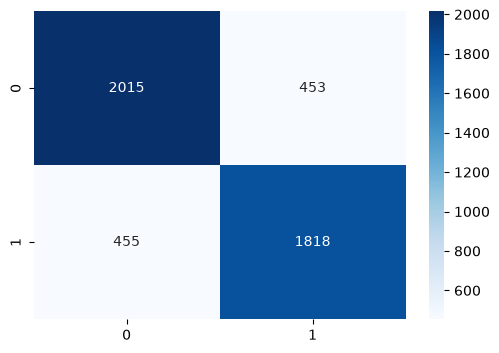

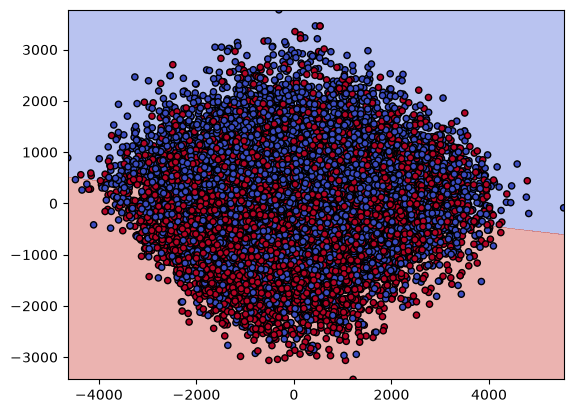

In [11]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_gender_train)
y_gender_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_gender_test, y_gender_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

log_reg_2d = LogisticRegression(max_iter=1000)
log_reg_2d.fit(X_train[:, :2], y_gender_train)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))
Z = log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_gender_train, s=20, edgecolor='k', cmap='coolwarm')
plt.show()

15.242136001586914
383.5419616699219
12.230118751525879
247.01028442382812
0.8084792237924489
0.8005284015852048
0.7998240211174659
0.8001760563380281


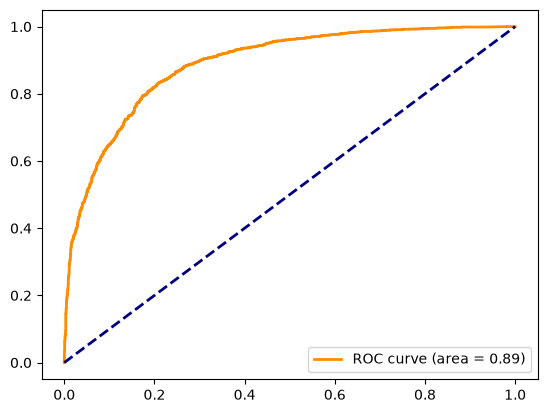

In [12]:
print(mean_absolute_error(y_age_test, y_age_pred_simple))
print(mean_squared_error(y_age_test, y_age_pred_simple))
print(mean_absolute_error(y_age_test, y_age_pred_multi))
print(mean_squared_error(y_age_test, y_age_pred_multi))

print(accuracy_score(y_gender_test, y_gender_pred))
print(precision_score(y_gender_test, y_gender_pred))
print(recall_score(y_gender_test, y_gender_pred))
print(f1_score(y_gender_test, y_gender_pred))

y_gender_prob = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_gender_test, y_gender_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.legend(loc="lower right")
plt.show()